In [1]:
%pip install -q mediapipe opencv-python matplotlib pandas ipython


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import shutil
import ssl
import subprocess
import urllib.request
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.core.base_options import BaseOptions

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["font.size"] = 12

print("mediapipe", getattr(mp, "__version__", "unknown"))
print(getattr(mp, "__file__", "built-in"))

mediapipe 0.10.33
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mediapipe/__init__.py


In [3]:
def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "assets" / "test-webcam.mp4").exists():
            return candidate
    raise FileNotFoundError("Не найден assets/test-webcam.mp4")


PROJECT_ROOT = find_project_root()
RESEARCH_DIR = PROJECT_ROOT / "tracking" / "research"
OUTPUT_DIR = RESEARCH_DIR / "mediapipe_outputs"
MODEL_DIR = OUTPUT_DIR / "models"
WEBCAM_VIDEO = PROJECT_ROOT / "assets" / "test-webcam.mp4"
SCREEN_VIDEO = PROJECT_ROOT / "assets" / "test-screen.mp4"
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def download_file(url, path):
    try:
        import certifi
        context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(url, context=context) as response:
            path.write_bytes(response.read())
        return
    except Exception as first_error:
        if shutil.which("curl"):
            subprocess.run(["curl", "-L", "--fail", url, "-o", str(path)], check=True)
            return
        raise first_error


MODEL_URLS = {
    "face": "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
    "hand": "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
    "pose": "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task",
    "segmenter": "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_segmenter/float16/latest/selfie_segmenter.tflite",
}

MODEL_PATHS = {
    "face": MODEL_DIR / "face_landmarker.task",
    "hand": MODEL_DIR / "hand_landmarker.task",
    "pose": MODEL_DIR / "pose_landmarker_lite.task",
    "segmenter": MODEL_DIR / "selfie_segmenter.tflite",
}

for name, url in MODEL_URLS.items():
    path = MODEL_PATHS[name]
    if not path.exists():
        print(f"download {name}")
        download_file(url, path)

print(PROJECT_ROOT)
print(WEBCAM_VIDEO)
print(OUTPUT_DIR)

download face
download hand
download pose
download segmenter
/Users/bim/mse1h2026-proc-gaze
/Users/bim/mse1h2026-proc-gaze/assets/test-webcam.mp4
/Users/bim/mse1h2026-proc-gaze/tracking/research/mediapipe_outputs


In [4]:
def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def as_mp_image(image):
    rgb = np.ascontiguousarray(bgr_to_rgb(image))
    return mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)


def show_bgr(title, image, figsize=(12, 7)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()


def read_frame(video_path, second=1.0):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise RuntimeError(f"Не удалось открыть видео: {video_path}")
    fps = capture.get(cv2.CAP_PROP_FPS) or 30
    total = int(capture.get(cv2.CAP_PROP_FRAME_COUNT) or 1)
    frame_index = min(max(int(second * fps), 0), total - 1)
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = capture.read()
    capture.release()
    if not ok:
        raise RuntimeError(f"Не удалось прочитать кадр {frame_index}")
    return frame, frame_index, fps


def video_info(video_path):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise RuntimeError(f"Не удалось открыть видео: {video_path}")
    fps = capture.get(cv2.CAP_PROP_FPS) or 0
    frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    capture.release()
    return {
        "file": video_path.name,
        "fps": round(fps, 2),
        "frames": frames,
        "duration_sec": round(frames / fps, 2) if fps else None,
        "width": width,
        "height": height,
    }


def landmark_xy(landmarks, index, width, height):
    point = landmarks[index]
    return np.array([point.x * width, point.y * height], dtype=np.float32)


def mean_landmark(landmarks, indices, width, height):
    return np.mean([landmark_xy(landmarks, index, width, height) for index in indices], axis=0)


def draw_points(image, landmarks, color=(120, 255, 160), radius=1, indices=None):
    height, width = image.shape[:2]
    selected = range(len(landmarks)) if indices is None else indices
    for index in selected:
        point = landmark_xy(landmarks, index, width, height)
        cv2.circle(image, tuple(np.round(point).astype(int)), radius, color, -1)


def draw_connections(image, landmarks, connections, color=(80, 220, 255), thickness=1):
    height, width = image.shape[:2]
    for connection in connections:
        start = landmark_xy(landmarks, connection.start, width, height)
        end = landmark_xy(landmarks, connection.end, width, height)
        cv2.line(image, tuple(np.round(start).astype(int)), tuple(np.round(end).astype(int)), color, thickness)


display(pd.DataFrame([video_info(WEBCAM_VIDEO), video_info(SCREEN_VIDEO)]))

,file,fps,frames,duration_sec,width,height
0,test-webcam.mp4,60.0,1865,31.08,1280,720
1,test-screen.mp4,60.0,1870,31.17,2560,1440


frame: 120
time: 2.00s


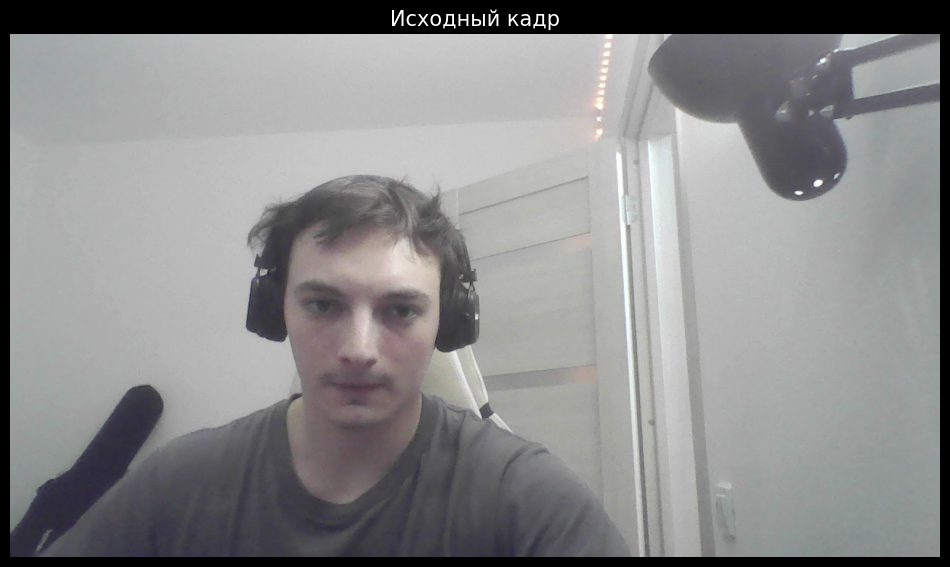

In [5]:
frame, frame_index, webcam_fps = read_frame(WEBCAM_VIDEO, second=2.0)

print(f"frame: {frame_index}")
print(f"time: {frame_index / webcam_fps:.2f}s")
show_bgr("Исходный кадр", frame)

## Лицо

Находим лицо, контуры, глаза, губы и радужки.

W0000 00:00:1776810899.449133   19647 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1776810899.633530   19647 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1776810899.636410   19650 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776810899.652173   19654 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


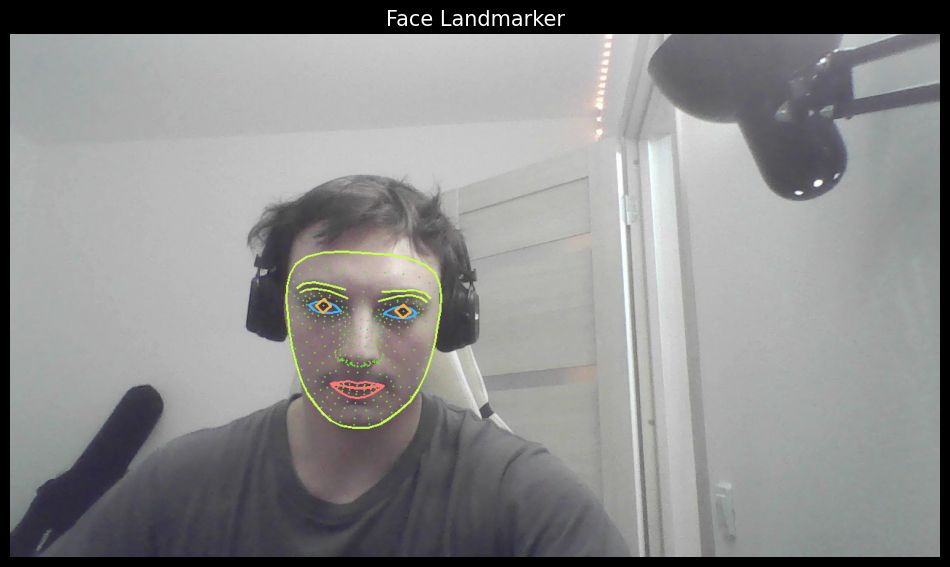

faces: 1
landmarks: 478


,blendshape,score
19,eyeSquintLeft,0.364
15,eyeLookOutLeft,0.304
20,eyeSquintRight,0.214
1,browDownLeft,0.193
36,mouthPressLeft,0.183
17,eyeLookUpLeft,0.176
18,eyeLookUpRight,0.159
2,browDownRight,0.152
9,eyeBlinkLeft,0.091
28,mouthDimpleLeft,0.086


In [6]:
face_options = vision.FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(MODEL_PATHS["face"])),
    running_mode=vision.RunningMode.IMAGE,
    num_faces=2,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

with vision.FaceLandmarker.create_from_options(face_options) as face_landmarker:
    face_result = face_landmarker.detect(as_mp_image(frame))

faces = face_result.face_landmarks
face_frame = frame.copy()

for face in faces:
    draw_points(face_frame, face, color=(70, 210, 120), radius=1)
    draw_connections(face_frame, face, vision.FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS, (80, 255, 200), 2)
    draw_connections(face_frame, face, vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYE, (255, 180, 70), 2)
    draw_connections(face_frame, face, vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYE, (255, 180, 70), 2)
    draw_connections(face_frame, face, vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS, (60, 180, 255), 2)
    draw_connections(face_frame, face, vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS, (60, 180, 255), 2)
    draw_connections(face_frame, face, vision.FaceLandmarksConnections.FACE_LANDMARKS_LIPS, (120, 120, 255), 2)

show_bgr("Face Landmarker", face_frame)
print(f"faces: {len(faces)}")
print(f"landmarks: {len(faces[0]) if faces else 0}")

if face_result.face_blendshapes:
    blendshape_rows = [
        {"blendshape": item.category_name, "score": round(item.score, 3)}
        for item in face_result.face_blendshapes[0]
    ]
    display(pd.DataFrame(blendshape_rows).sort_values("score", ascending=False).head(10))